# this notebook serves as the playground to learn and experiment Binarization. 
  Dataset link: https://archive.ics.uci.edu/dataset/2/adult

In [122]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Binarizer
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [123]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv("adult.csv",header=0, names=columns,)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [124]:
df = df[['age','hours_per_week','income']]
df.head(2)

,age,hours_per_week,income
0,39,40,<=50K
1,50,13,<=50K


In [125]:
X = df.drop(columns=["income"])
y = df['income']

In [126]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# fitting a model without binarization


In [127]:
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test,y_pred)


0.760939659143252

In [140]:
# cross validating
np.mean(cross_val_score(clf,X_train,y_train,cv=10,scoring='accuracy')) 

np.float64(0.7590985962832907)

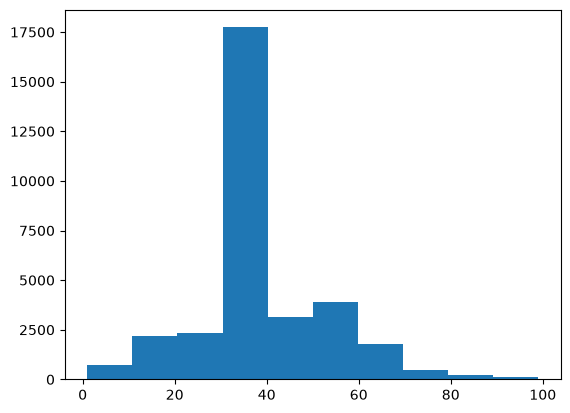

In [129]:
plt.hist(df['hours_per_week'])
plt.show()

# fitting a model with binarization


In [ ]:
ct = ColumnTransformer([
    ('binarizer',Binarizer(threshold=40,copy=False),['hours_per_week'])
],remainder='passthrough')

clf = DecisionTreeClassifier()
# X_train_transformed = ct.fit_transform(X_train)
# X_test_transformed = ct.transform(X_test)

# clf.fit(X_train_transformed,y_train)
# y_pred = clf.predict(X_test_transformed)

# accuracy_score(y_test,y_pred)

0.7655458314140949

In [137]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('transform',ct),
    ('classifier',clf)
])

pipe.fit(X_train,y_train)
y_pred = pipe.predict(X_test)
accuracy_score(y_test,y_pred)

0.7587901120835252

In [138]:
# cross validating 
np.mean(cross_val_score(pipe,X_train,y_train,cv=10,scoring='accuracy'))

np.float64(0.7590985962832907)